## 4.1 ディープラーニング向けライブラリの導入

### 4.1.1 Keras

In [1]:
import numpy as np
import tensorflow as tf
from sklearn import datasets
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import optimizers

In [ ]:
np.random.seed(123)
tf.random.set_seed(123)  # tensorflow用の乱数シード
"""
1. データの準備
"""
N = 300
x, t = datasets.make_moons(N, noise=0.3)
t = t.reshape(N, 1)
x_train, x_test, t_train, t_test = train_test_split(x, t, test_size=0.2)

"""
2. モデルの構築
"""
# Kerasではモデル構築を「ネットワークに層を追加していく」ことで直観的に記述できる.
# Sequentialクラスでネットワークをセットアップ.
model = Sequential()
# 空のモデルにaddメソッドで層を追加していく. chapter3のLayerがDenseに相当.
model.add(Dense(3, activation="sigmoid"))  # 隠れ層を追加
model.add(Dense(1, activation="sigmoid"))  # 出力層を追加

"""
3. モデルの学習
"""
optimizer = optimizers.SGD(learning_rate=0.1)
# モデルをどのように学習するかをcompileメソッドで設定.
model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
# 学習を行う.
model.fit(x_train, t_train, epochs=100, batch_size=10, verbose=1)

"""
4. モデルの評価
"""
loss, acc = model.evaluate(x_test, t_test, verbose=0)
display(f"test_loss: {loss:.3f}, test_acc: {acc:.3f}")
# 出力はmodel.predict(x_test)で得られる. 分類後出力はmodel.predict_classes(x_test)で得られる.

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5393 - loss: 0.6884  
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5393 - loss: 0.6770 
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5698 - loss: 0.6651 
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6699 - loss: 0.6525 
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7649 - loss: 0.6392 
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7932 - loss: 0.6251 
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7903 - loss: 0.6105 
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7998 - loss: 0.5955 
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8098 - loss: 0.5805 
Epoch 10/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7976 - loss: 0.5657 
Epoch 11/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7963 - loss: 0.5515 
Epoch 12/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

'test_loss: 0.306, test_acc: 0.867'

### 4.1.2 TensorFlow

In [2]:
from typing import Any

import numpy as np
import tensorflow as tf
from sklearn import datasets
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras import optimizers
from tensorflow.keras import losses
from tensorflow.keras import metrics

In [ ]:
np.random.seed(123)
tf.random.set_seed(123)
"""
1. データの準備
"""
N = 300
x, t = datasets.make_moons(N, noise=0.3)
t = t.reshape(N, 1)
x_train, x_test, t_train, t_test = train_test_split(x, t, test_size=0.2)

"""
2. モデルの構築
"""


# tensorflow.keras.Modelをカスタマイズする形で実装.
class MLP(Model):
    """
    多層パーセプトロン
    """

    def __init__(self, hidden_dim: int, output_dim: int) -> None:
        super().__init__()
        # Layerの代わりにDenseを使う.
        self.l1 = Dense(hidden_dim, activation="sigmoid")
        self.l2 = Dense(output_dim, activation="sigmoid")

    def call(self, x: np.ndarray) -> np.ndarray:
        # 順伝播計算.
        h = self.l1(x)
        y = self.l2(h)
        return y


model = MLP(3, 1)

"""
3. モデルの学習
"""
criterion = losses.BinaryCrossentropy()
optimizer = optimizers.SGD(learning_rate=0.1)


def compute_loss(t: np.ndarray, y: np.ndarray) -> tf.Tensor:
    return criterion(t, y)


def train_step(model: MLP, x: np.ndarray, t: np.ndarray) -> tuple[tf.Tensor, MLP]:
    # tensorflowが自動で勾配を計算.
    with tf.GradientTape() as tape:
        preds = model(x)
        loss = compute_loss(t, preds)
    grads = tape.gradient(loss, model.trainable_variables)
    # 勾配からパラメータを更新.
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss, model


epochs = 100
batch_size = 10
n_batches = x_train.shape[0] // batch_size
for epoch in range(epochs):
    train_loss = 0.0
    x_, t_ = shuffle(x_train, t_train)
    for batch in range(n_batches):
        start = batch * batch_size
        end = start + batch_size
        loss, model = train_step(model, x_[start:end], t_[start:end])
        train_loss += loss.numpy()
    display(f"epoch: {epoch + 1}, loss: {train_loss:.3f}")

"""
4. モデルの評価
"""
test_loss = metrics.Mean()  # 誤差関数を求めるためのオブジェクト
test_acc = metrics.BinaryAccuracy()  # 正解率を求めるためのオブジェクト


def test_step(model: MLP, x: np.ndarray, t: np.ndarray) -> tuple[np.ndarray, Any, Any]:
    preds = model(x)
    loss = compute_loss(t, preds)
    test_loss(loss)
    test_acc(t, preds)
    return preds, test_loss, test_acc


_, test_loss, test_acc = test_step(model, x_test, t_test)
display(f"test_loss: {test_loss.result():.3f}, test_acc: {test_acc.result():.3f}")

'epoch: 1, loss: 16.484'

'epoch: 2, loss: 15.870'

'epoch: 3, loss: 15.347'

'epoch: 4, loss: 14.840'

'epoch: 5, loss: 14.379'

...

'epoch: 97, loss: 9.324'

'epoch: 98, loss: 9.323'

'epoch: 99, loss: 9.323'

'epoch: 100, loss: 9.320'

'test_loss: 0.313, test_acc: 0.867'

### 4.1.3 PyTorch

In [3]:
from typing import Callable

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optimizers

from sklearn import datasets
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from torch.nn.modules import Module
from torch.optim import Optimizer

In [ ]:
class MLP(Module):
    """
    多層パーセプトロン
    """

    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int) -> None:
        super().__init__()
        # KerasのDenseに対応する.
        self.l1 = nn.Linear(input_dim, hidden_dim)
        # 活性化関数は別で定義.
        self.a1 = nn.Sigmoid()
        self.l2 = nn.Linear(hidden_dim, output_dim)
        self.a2 = nn.Sigmoid()
        # 順伝播計算用のリスト
        self.layers = [self.l1, self.a2, self.l2, self.a2]

    def forward(self, x: np.ndarray) -> np.ndarray:
        for layer in self.layers:
            x = layer(x)
        return x

In [ ]:
np.random.seed(123)
torch.manual_seed(123)  # torch用の乱数シード
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
"""
1. データの準備
"""
N = 300
x, t = datasets.make_moons(N, noise=0.3)
t = t.reshape(N, 1)
x_train, x_test, t_train, t_test = train_test_split(x, t, test_size=0.2)

"""
2. モデルの構築
"""
# GPU利用可能な環境ならGPUを利用するように設定.
model = MLP(2, 3, 1).to(device)

"""
3. モデルの学習
"""
criterion = nn.BCELoss()
optimizer = optimizers.SGD(model.parameters(), lr=0.1)


def compute_loss(t: torch.Tensor, y: torch.Tensor) -> Module:
    return criterion(y, t)


def train_step(
    model: Module, optimizer: Optimizer, x: torch.Tensor, t: torch.Tensor
) -> tuple[Module, Module, Optimizer]:
    # モデルを学習モードに切り替える.
    model.train()
    preds = model(x)
    loss = compute_loss(t, preds)
    optimizer.zero_grad()  # 勾配の初期化
    loss.backward()  # 勾配計算
    optimizer.step()  # パラメータ更新
    return loss, model, optimizer


epochs = 100
batch_size = 10
n_batches = x_train.shape[0] // batch_size
for epoch in range(epochs):
    train_loss = 0.0
    x_, t_ = shuffle(x_train, t_train)
    # numpy配列データをtorch.Tensorに変換.
    x_ = torch.Tensor(x_).to(device)
    t_ = torch.Tensor(t_).to(device)
    for n_batch in range(n_batches):
        start = n_batch * batch_size
        end = start + batch_size
        loss, model, optimizer = train_step(
            model, optimizer, x_[start:end], t_[start:end]
        )
        train_loss += loss.item()
    display(f"epoch: {epoch + 1}, loss: {train_loss:.3f}")

"""
4. モデルの評価
"""


def test_step(
    model: Module, x: np.ndarray, t: np.ndarray
) -> tuple[Module, torch.Tensor]:
    x = torch.Tensor(x).to(device)
    t = torch.Tensor(t).to(device)
    # モデルを推論モードに切り替える.
    model.eval()
    preds = model(x)
    loss = compute_loss(t, preds)
    return loss, preds


loss, preds = test_step(model, x_test, t_test)
test_loss = loss.item()
# モデルの出力をnumpy配列に変換
# preds: 勾配計算の情報を含むテンソル型
# preds.data: 勾配計算の情報を含まないテンソル型
# preds.data.cpu(): CPUのテンソル型
# preds.data.cpu().numpy(): numpy配列
preds = preds.data.cpu().numpy() > 0.5
test_acc = accuracy_score(t_test, preds)
display(f"test_loss: {test_loss:.3f}, test_acc: {test_acc:.3f}")

'epoch: 1, loss: 17.123'

'epoch: 2, loss: 16.806'

'epoch: 3, loss: 16.587'

'epoch: 4, loss: 16.362'

'epoch: 5, loss: 16.137'

...

'epoch: 97, loss: 9.370'

'epoch: 98, loss: 9.367'

'epoch: 99, loss: 9.368'

'epoch: 100, loss: 9.364'

'test_loss: 0.302, test_acc: 0.867'

## 4.2 ディープラーニングへの準備

### 4.2.1 学習における問題

In [6]:
from tensorflow.keras import datasets


mnist = datasets.mnist
(x_train, t_train), (x_test, t_test) = mnist.load_data()

In [7]:
x_train = (x_train.reshape(-1, 784) / 255).astype(np.float32)
x_test = (x_test.reshape(-1, 784) / 255).astype(np.float32)
t_train = np.eye(10)[t_train].astype(np.float32)  # 1-of-K表現に変換
t_test = np.eye(10)[t_test].astype(np.float32)

In [31]:
model = Sequential()
model.add(Dense(200, activation="sigmoid"))
model.add(Dense(10, activation="softmax"))
model.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])
model.fit(x_train, t_train, epochs=30, batch_size=100, verbose=2)

loss, acc = model.evaluate(x_test, t_test, verbose=0)
display(f"test_loss: {loss:.3f}, test_acc: {acc:.3f}")

Epoch 1/30
600/600 - 1s - 2ms/step - accuracy: 0.5541 - loss: 1.9457
Epoch 2/30
600/600 - 1s - 2ms/step - accuracy: 0.7692 - loss: 1.3301
Epoch 3/30
600/600 - 1s - 2ms/step - accuracy: 0.8164 - loss: 0.9715
Epoch 4/30
600/600 - 1s - 2ms/step - accuracy: 0.8392 - loss: 0.7802
Epoch 5/30
600/600 - 1s - 2ms/step - accuracy: 0.8518 - loss: 0.6686
Epoch 6/30
600/600 - 1s - 2ms/step - accuracy: 0.8616 - loss: 0.5967
Epoch 7/30
600/600 - 1s - 2ms/step - accuracy: 0.8691 - loss: 0.5466
Epoch 8/30
600/600 - 1s - 2ms/step - accuracy: 0.8745 - loss: 0.5097
Epoch 9/30
600/600 - 1s - 2ms/step - accuracy: 0.8787 - loss: 0.4814
Epoch 10/30
600/600 - 1s - 2ms/step - accuracy: 0.8819 - loss: 0.4590
Epoch 11/30
600/600 - 1s - 2ms/step - accuracy: 0.8853 - loss: 0.4410
Epoch 12/30
600/600 - 1s - 2ms/step - accuracy: 0.8880 - loss: 0.4259
Epoch 13/30
600/600 - 1s - 2ms/step - accuracy: 0.8901 - loss: 0.4132
Epoch 14/30
600/600 - 1s - 2ms/step - accuracy: 0.8918 - loss: 0.4024
Epoch 15/30
600/600 - 1s - 2m

'test_loss: 0.308, test_acc: 0.914'

In [13]:
from tensorflow.keras.layers import LeakyReLU


model = Sequential()
#model.add(Dense(200, activation="sigmoid"))
#model.add(Dense(200, activation="sigmoid"))
#model.add(Dense(200, activation="sigmoid"))
#model.add(Dense(200, activation="tanh"))
#model.add(Dense(200, activation="tanh"))
#model.add(Dense(200, activation="tanh"))
#model.add(Dense(200, activation="relu"))
#model.add(Dense(200, activation="relu"))
#model.add(Dense(200, activation="relu"))
model.add(Dense(200))
model.add(LeakyReLU(0.01))
model.add(Dense(200))
model.add(LeakyReLU(0.01))
model.add(Dense(200))
model.add(LeakyReLU(0.01))
model.add(Dense(10, activation="softmax"))
model.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])
model.fit(x_train, t_train, epochs=30, batch_size=100, verbose=2)

loss, acc = model.evaluate(x_test, t_test, verbose=0)
display(f"test_loss: {loss:.3f}, test_acc: {acc:.3f}")

Epoch 1/30
600/600 - 2s - 3ms/step - accuracy: 0.7294 - loss: 1.1216
Epoch 2/30
600/600 - 1s - 2ms/step - accuracy: 0.8873 - loss: 0.4030
Epoch 3/30
600/600 - 1s - 2ms/step - accuracy: 0.9064 - loss: 0.3267
Epoch 4/30
600/600 - 1s - 2ms/step - accuracy: 0.9176 - loss: 0.2886
Epoch 5/30
600/600 - 1s - 2ms/step - accuracy: 0.9252 - loss: 0.2614
Epoch 6/30
600/600 - 1s - 2ms/step - accuracy: 0.9311 - loss: 0.2397
Epoch 7/30
600/600 - 1s - 2ms/step - accuracy: 0.9365 - loss: 0.2216
Epoch 8/30
600/600 - 1s - 2ms/step - accuracy: 0.9411 - loss: 0.2061
Epoch 9/30
600/600 - 1s - 2ms/step - accuracy: 0.9446 - loss: 0.1926
Epoch 10/30
600/600 - 1s - 2ms/step - accuracy: 0.9485 - loss: 0.1808
Epoch 11/30
600/600 - 1s - 2ms/step - accuracy: 0.9510 - loss: 0.1703
Epoch 12/30
600/600 - 1s - 2ms/step - accuracy: 0.9537 - loss: 0.1609
Epoch 13/30
600/600 - 1s - 2ms/step - accuracy: 0.9565 - loss: 0.1524
Epoch 14/30
600/600 - 1s - 2ms/step - accuracy: 0.9585 - loss: 0.1446
Epoch 15/30
600/600 - 1s - 2m

'test_loss: 0.094, test_acc: 0.970'

### 4.2.4　実装の準備

#### 4.2.4.1 Keras

省略(4.2.1参照)

#### 4.2.4.2 TensorFlow

In [9]:
from typing import Any

import numpy as np
import tensorflow as tf

from sklearn.utils import shuffle
from tensorflow.keras import datasets
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras import optimizers
from tensorflow.keras import losses
from tensorflow.keras import metrics

In [ ]:
from tensorflow.keras.layers import LeakyReLU


class DNN(Model):
    def __init__(self, hidden_dim: int, output_dim: int) -> None:
        super().__init__()
        #self.l1 = Dense(hidden_dim, activation="sigmoid")
        #self.l2 = Dense(hidden_dim, activation="sigmoid")
        #self.l3 = Dense(hidden_dim, activation="sigmoid")
        #self.l1 = Dense(hidden_dim, activation="tanh")
        #self.l2 = Dense(hidden_dim, activation="tanh")
        #self.l3 = Dense(hidden_dim, activation="tanh")
        #self.l1 = Dense(hidden_dim, activation="relu")
        #self.l2 = Dense(hidden_dim, activation="relu")
        #self.l3 = Dense(hidden_dim, activation="relu")
        self.l1 = Dense(hidden_dim)
        self.a1 = LeakyReLU(0.01)
        self.l2 = Dense(hidden_dim)
        self.a2 = LeakyReLU(0.01)
        self.l3 = Dense(hidden_dim)
        self.a3 = LeakyReLU(0.01)
        self.l4 = Dense(output_dim, activation="softmax")
        self.ls = [self.l1, self.l2, self.l3, self.l4]

    def call(self, x: np.ndarray) -> np.ndarray:
        for layer in self.ls:
            x = layer(x)
        return x

In [11]:
# Kerasより遅く感じる
np.random.seed(123)
tf.random.set_seed(123)
"""
1. データの準備
"""
mnist = datasets.mnist
(x_train, t_train), (x_test, t_test) = mnist.load_data()

x_train = (x_train.reshape(-1, 784) / 255).astype(np.float32)
x_test = (x_test.reshape(-1, 784) / 255).astype(np.float32)
t_train = np.eye(10)[t_train].astype(np.float32)
t_test = np.eye(10)[t_test].astype(np.float32)

"""
2. モデルの構築
"""
model = DNN(200, 10)

"""
3. モデルの学習
"""
criterion = losses.CategoricalCrossentropy()  # 多クラス問題の分類損失関数
optimizer = optimizers.SGD(learning_rate=0.01)
train_loss = metrics.Mean()
train_acc = metrics.CategoricalAccuracy()  # 多クラス問題の正解率


def compute_loss(t: np.ndarray, y: np.ndarray) -> tf.Tensor:
    return criterion(t, y)


def train_step(
    model: DNN,
    optimizer: Any,
    trian_loss: Any,
    tran_acc: Any,
    x: np.ndarray,
    t: np.ndarray,
) -> tuple[tf.Tensor, DNN, Any, Any, Any]:
    with tf.GradientTape() as tape:
        preds = model(x)
        loss = compute_loss(t, preds)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    train_loss(loss)
    train_acc(t, preds)
    return loss, model, optimizer, train_loss, train_acc


epochs = 30
batch_size = 100
n_batches = x_train.shape[0] // batch_size
for epoch in range(epochs):
    x_, t_ = shuffle(x_train, t_train)
    for batch in range(n_batches):
        start = batch * batch_size
        end = start + batch_size
        _, model, optimizer, train_loss, train_acc = train_step(
            model, optimizer, train_loss, train_acc, x_[start:end], t_[start:end]
        )
    display(
        f"epoch: {epoch + 1}, loss: {train_loss.result():.3f}, acc: {train_acc.result():.3f}"
    )

"""
4. モデルの評価
"""
test_loss = metrics.Mean()
test_acc = metrics.CategoricalAccuracy()


def test_step(
    test_loss: Any, test_acc: Any, x: np.ndarray, t: np.ndarray
) -> tuple[tf.Tensor, Any, Any]:
    preds = model(x)
    loss = compute_loss(t, preds)
    test_loss(loss)
    test_acc(t, preds)
    return loss, test_loss, test_acc


_, test_loss, test_acc = test_step(test_loss, test_acc, x_test, t_test)
display(f"test_loss: {test_loss.result():.3f}, test_acc: {test_acc.result():.3f}")

'epoch: 1, loss: 0.797, acc: 0.800'

'epoch: 2, loss: 0.596, acc: 0.846'

'epoch: 3, loss: 0.510, acc: 0.865'

'epoch: 4, loss: 0.459, acc: 0.877'

'epoch: 5, loss: 0.425, acc: 0.885'

...

'epoch: 27, loss: 0.225, acc: 0.936'

'epoch: 28, loss: 0.221, acc: 0.938'

'epoch: 29, loss: 0.217, acc: 0.939'

'epoch: 30, loss: 0.214, acc: 0.940'

'test_loss: 0.120, test_acc: 0.964'

#### 4.2.4.3 PyTorch

In [40]:
import os
from torchvision import datasets


root = os.path.join("~", ".torch", "mnist")
mnist_train = datasets.MNIST(root=root, download=True, train=True)
for datum in mnist_train:
    display(datum)
    break

100.0%
100.0%
100.0%
100.0%


(<PIL.Image.Image image mode=L size=28x28>, 5)

In [46]:
from torchvision import datasets
import torchvision.transforms as transforms


# transforms.ToTensor: Imageオブジェクトをテンソル型に変換
# lambda x: x.view(-1): テンソルの次元を(28, 28)から(784,)に変換
transform = transforms.Compose([transforms.ToTensor(), lambda x: x.view(-1)])
mnist_train = datasets.MNIST(root=root, download=True, train=True, transform=transform)

In [ ]:
from torch.utils.data import DataLoader


# batch_size: バッチ単位でデータをイテレーションできる
# shuffle: 各エポックでデータシャッフル処理を行ってくれる
train_dataloader = DataLoader(mnist_train, batch_size=100, shuffle=True)

In [48]:
for (x, t) in train_dataloader:
    display(x.shape)
    break

torch.Size([100, 784])

In [5]:
import os

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optimizers
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader
from torchvision import datasets
from torch.optim import Optimizer

In [ ]:
class DNN(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int) -> None:
        super().__init__()
        self.l1 = nn.Linear(input_dim, hidden_dim)
        #self.a1 = nn.Sigmoid()
        #self.a1 = nn.Tanh()
        #self.a1 = nn.ReLU()
        self.a1 = nn.LeakyReLU(0.01)
        self.l2 = nn.Linear(hidden_dim, hidden_dim)
        #self.a2 = nn.Sigmoid()
        #self.a2 = nn.Tanh()
        #self.a2 = nn.ReLU()
        self.a2 = nn.LeakyReLU(0.01)
        self.l3 = nn.Linear(hidden_dim, hidden_dim)
        #self.a3 = nn.Sigmoid()
        #self.a3 = nn.Tanh()
        #self.a3 = nn.ReLU()
        self.a3 = nn.LeakyReLU(0.01)
        self.l4 = nn.Linear(hidden_dim, output_dim)
        self.layers = [self.l1, self.a1, self.l2, self.a2, self.l3, self.a3, self.l4]

    def forward(self, x: np.ndarray) -> np.ndarray:
        for layer in self.layers:
            x = layer(x)
        return x

In [ ]:
# 正解率が低いのはなぜ？
np.random.seed(123)
torch.manual_seed(123)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
"""
1. データの準備
"""
root = os.path.join("~", ".torch", "mnist")
transform = transforms.Compose([transforms.ToTensor(), lambda x: x.view(-1)])
mnist_train = datasets.MNIST(root=root, download=True, train=True, transform=transform)
mnist_test = datasets.MNIST(root=root, download=True, train=False, transform=transform)
train_dataloader = DataLoader(mnist_train, batch_size=100, shuffle=True)
test_dataloader = DataLoader(mnist_test, batch_size=100, shuffle=False)

"""
2. モデルの構築
"""
model = DNN(784, 200, 10).to(device)

"""
3. モデルの学習
"""
criterion = nn.CrossEntropyLoss()
optimizer = optimizers.SGD(model.parameters(), lr=0.01)


def compute_loss(t: torch.Tensor, y: torch.Tensor) -> nn.Module:
    return criterion(y, t)


def train_step(
    model: nn.Module, optimizer: Optimizer, x: torch.Tensor, t: torch.Tensor
) -> tuple[nn.Module, nn.Module, nn.Module, Optimizer]:
    model.train()
    preds = model(x)
    loss = compute_loss(t, preds)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss, preds, model, optimizer


epochs = 30
for epoch in range(epochs):
    train_loss = 0.0
    train_acc = 0.0
    for x, t in train_dataloader:
        x, t = x.to(device), t.to(device)
        loss, preds, model, optimizer = train_step(model, optimizer, x, t)
        train_loss += loss.item()
        train_acc += accuracy_score(t.tolist(), preds.argmax(dim=-1).tolist())
    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)
    display(f"epoch: {epoch + 1}, loss: {train_loss:.3f}, acc: {train_acc:.3f}")

"""
4. モデルの評価
"""


def test_step(
    model: nn.Module, x: torch.Tensor, t: torch.Tensor
) -> tuple[nn.Module, torch.Tensor, nn.Module]:
    model.eval()
    preds = model(x)
    loss = criterion(preds, t)
    return loss, preds, model


test_loss = 0.0
test_acc = 0.0
for x, t in test_dataloader:
    x, t = x.to(device), t.to(device)
    loss, preds, model = test_step(model, x, t)
    test_loss += loss.item()
    test_acc += accuracy_score(t.tolist(), preds.argmax(dim=-1).tolist())
test_loss /= len(test_dataloader)
test_acc /= len(test_dataloader)
display(f"test_loss: {test_loss:.3f}, test_acc: {test_acc:.3f}")

'epoch: 1, loss: 2.303, acc: 0.111'

'epoch: 2, loss: 2.302, acc: 0.111'

'epoch: 3, loss: 2.302, acc: 0.110'

'epoch: 4, loss: 2.302, acc: 0.109'

'epoch: 5, loss: 2.302, acc: 0.112'

...

'epoch: 27, loss: 2.297, acc: 0.121'

'epoch: 28, loss: 2.297, acc: 0.122'

'epoch: 29, loss: 2.296, acc: 0.124'

'epoch: 30, loss: 2.295, acc: 0.128'

'test_loss: 2.294, test_acc: 0.113'

### 4.3.4 Swish

#### Keras

In [ ]:
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras import backend as K


def swish(x: np.ndarray, beta: float = 1.) -> np.ndarray:
    return x * K.sigmoid(beta * x)


model = Sequential()
model.add(Dense(200, activation=lambda x: swish(x, beta=1.)))
model.add(Dense(200, activation=lambda x: swish(x, beta=1.)))
model.add(Dense(200, activation=lambda x: swish(x, beta=1.)))
model.add(Dense(10, activation="softmax"))
model.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])
model.fit(x_train, t_train, epochs=30, batch_size=100, verbose=2)

loss, acc = model.evaluate(x_test, t_test, verbose=0)
display(f"test_loss: {loss:.3f}, test_acc: {acc:.3f}")

Epoch 1/30
600/600 - 2s - 3ms/step - accuracy: 0.5692 - loss: 1.8471
Epoch 2/30
600/600 - 1s - 2ms/step - accuracy: 0.8398 - loss: 0.5937
Epoch 3/30
600/600 - 1s - 2ms/step - accuracy: 0.8867 - loss: 0.3994
Epoch 4/30
600/600 - 1s - 2ms/step - accuracy: 0.9004 - loss: 0.3484
Epoch 5/30
600/600 - 1s - 2ms/step - accuracy: 0.9091 - loss: 0.3204
Epoch 6/30
600/600 - 1s - 2ms/step - accuracy: 0.9146 - loss: 0.3005
Epoch 7/30
600/600 - 1s - 2ms/step - accuracy: 0.9194 - loss: 0.2840
Epoch 8/30
600/600 - 1s - 2ms/step - accuracy: 0.9236 - loss: 0.2693
Epoch 9/30
600/600 - 1s - 2ms/step - accuracy: 0.9278 - loss: 0.2556
Epoch 10/30
600/600 - 1s - 2ms/step - accuracy: 0.9313 - loss: 0.2427
Epoch 11/30
600/600 - 1s - 2ms/step - accuracy: 0.9348 - loss: 0.2307
Epoch 12/30
600/600 - 1s - 2ms/step - accuracy: 0.9376 - loss: 0.2195
Epoch 13/30
600/600 - 1s - 2ms/step - accuracy: 0.9405 - loss: 0.2091
Epoch 14/30
600/600 - 1s - 2ms/step - accuracy: 0.9431 - loss: 0.1994
Epoch 15/30
600/600 - 1s - 2m

'test_loss: 0.121, test_acc: 0.963'

#### TensorFlow

In [15]:
from typing import Any

import numpy as np
import tensorflow as tf

from sklearn.utils import shuffle
from tensorflow.keras import datasets
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras import optimizers
from tensorflow.keras import losses
from tensorflow.keras import metrics

In [ ]:
from tensorflow.keras.layers import LeakyReLU


def swish(x: np.ndarray, beta: float = 1.0) -> np.ndarray:
    return x * tf.nn.sigmoid(beta * x)


class DNN(Model):
    def __init__(self, hidden_dim: int, output_dim: int) -> None:
        super().__init__()
        self.l1 = Dense(hidden_dim, activation=lambda x: swish(x, beta=1.))
        self.l2 = Dense(hidden_dim, activation=lambda x: swish(x, beta=1.))
        self.l3 = Dense(hidden_dim, activation=lambda x: swish(x, beta=1.))
        self.l4 = Dense(output_dim, activation="softmax")
        self.ls = [self.l1, self.l2, self.l3, self.l4]

    def call(self, x: np.ndarray) -> np.ndarray:
        for layer in self.ls:
            x = layer(x)
        return x

In [ ]:
# Kerasより遅く感じる
np.random.seed(123)
tf.random.set_seed(123)
"""
1. データの準備
"""
mnist = datasets.mnist
(x_train, t_train), (x_test, t_test) = mnist.load_data()

x_train = (x_train.reshape(-1, 784) / 255).astype(np.float32)
x_test = (x_test.reshape(-1, 784) / 255).astype(np.float32)
t_train = np.eye(10)[t_train].astype(np.float32)
t_test = np.eye(10)[t_test].astype(np.float32)

"""
2. モデルの構築
"""
model = DNN(200, 10)

"""
3. モデルの学習
"""
criterion = losses.CategoricalCrossentropy()  # 多クラス問題の分類損失関数
optimizer = optimizers.SGD(learning_rate=0.01)
train_loss = metrics.Mean()
train_acc = metrics.CategoricalAccuracy()  # 多クラス問題の正解率


def compute_loss(t: np.ndarray, y: np.ndarray) -> tf.Tensor:
    return criterion(t, y)


def train_step(
    model: DNN,
    optimizer: Any,
    trian_loss: Any,
    tran_acc: Any,
    x: np.ndarray,
    t: np.ndarray,
) -> tuple[tf.Tensor, DNN, Any, Any, Any]:
    with tf.GradientTape() as tape:
        preds = model(x)
        loss = compute_loss(t, preds)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    train_loss(loss)
    train_acc(t, preds)
    return loss, model, optimizer, train_loss, train_acc


epochs = 30
batch_size = 100
n_batches = x_train.shape[0] // batch_size
for epoch in range(epochs):
    x_, t_ = shuffle(x_train, t_train)
    for batch in range(n_batches):
        start = batch * batch_size
        end = start + batch_size
        _, model, optimizer, train_loss, train_acc = train_step(
            model, optimizer, train_loss, train_acc, x_[start:end], t_[start:end]
        )
    display(
        f"epoch: {epoch + 1}, loss: {train_loss.result():.3f}, acc: {train_acc.result():.3f}"
    )

"""
4. モデルの評価
"""
test_loss = metrics.Mean()
test_acc = metrics.CategoricalAccuracy()


def test_step(
    test_loss: Any, test_acc: Any, x: np.ndarray, t: np.ndarray
) -> tuple[tf.Tensor, Any, Any]:
    preds = model(x)
    loss = compute_loss(t, preds)
    test_loss(loss)
    test_acc(t, preds)
    return loss, test_loss, test_acc


_, test_loss, test_acc = test_step(test_loss, test_acc, x_test, t_test)
display(f"test_loss: {test_loss.result():.3f}, test_acc: {test_acc.result():.3f}")

### PyTorch

In [16]:
import os

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optimizers
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader
from torchvision import datasets
from torch.optim import Optimizer

In [ ]:
class Swish(nn.Module):
    def __init__(self, beta: float = 1.) -> None:
        super().__init__()
        self.beta = beta

    def forward(self, x: np.ndarray) -> np.ndarray:
        return x * torch.sigmoid(self.beta * x)


class DNN(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int) -> None:
        super().__init__()
        self.l1 = nn.Linear(input_dim, hidden_dim)
        self.a1 = Swish()
        self.l2 = nn.Linear(hidden_dim, hidden_dim)
        self.a2 = Swish()
        self.l3 = nn.Linear(hidden_dim, hidden_dim)
        self.a3 = Swish()
        self.l4 = nn.Linear(hidden_dim, output_dim)
        self.layers = [self.l1, self.a1, self.l2, self.a2, self.l3, self.a3, self.l4]

    def forward(self, x: np.ndarray) -> np.ndarray:
        for layer in self.layers:
            x = layer(x)
        return x

In [ ]:
# 正解率が低いのはなぜ？
np.random.seed(123)
torch.manual_seed(123)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
"""
1. データの準備
"""
root = os.path.join("~", ".torch", "mnist")
transform = transforms.Compose([transforms.ToTensor(), lambda x: x.view(-1)])
mnist_train = datasets.MNIST(root=root, download=True, train=True, transform=transform)
mnist_test = datasets.MNIST(root=root, download=True, train=False, transform=transform)
train_dataloader = DataLoader(mnist_train, batch_size=100, shuffle=True)
test_dataloader = DataLoader(mnist_test, batch_size=100, shuffle=False)

"""
2. モデルの構築
"""
model = DNN(784, 200, 10).to(device)

"""
3. モデルの学習
"""
criterion = nn.CrossEntropyLoss()
optimizer = optimizers.SGD(model.parameters(), lr=0.01)


def compute_loss(t: torch.Tensor, y: torch.Tensor) -> nn.Module:
    return criterion(y, t)


def train_step(
    model: nn.Module, optimizer: Optimizer, x: torch.Tensor, t: torch.Tensor
) -> tuple[nn.Module, nn.Module, nn.Module, Optimizer]:
    model.train()
    preds = model(x)
    loss = compute_loss(t, preds)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss, preds, model, optimizer


epochs = 30
for epoch in range(epochs):
    train_loss = 0.0
    train_acc = 0.0
    for x, t in train_dataloader:
        x, t = x.to(device), t.to(device)
        loss, preds, model, optimizer = train_step(model, optimizer, x, t)
        train_loss += loss.item()
        train_acc += accuracy_score(t.tolist(), preds.argmax(dim=-1).tolist())
    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)
    display(f"epoch: {epoch + 1}, loss: {train_loss:.3f}, acc: {train_acc:.3f}")

"""
4. モデルの評価
"""


def test_step(
    model: nn.Module, x: torch.Tensor, t: torch.Tensor
) -> tuple[nn.Module, torch.Tensor, nn.Module]:
    model.eval()
    preds = model(x)
    loss = criterion(preds, t)
    return loss, preds, model


test_loss = 0.0
test_acc = 0.0
for x, t in test_dataloader:
    x, t = x.to(device), t.to(device)
    loss, preds, model = test_step(model, x, t)
    test_loss += loss.item()
    test_acc += accuracy_score(t.tolist(), preds.argmax(dim=-1).tolist())
test_loss /= len(test_dataloader)
test_acc /= len(test_dataloader)
display(f"test_loss: {test_loss:.3f}, test_acc: {test_acc:.3f}")

### 4.5.1 学習の可視化

#### 4.5.1.1 Keras

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import datasets
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

Epoch 1/100
480/480 - 2s - 4ms/step - accuracy: 0.2749 - loss: 2.0333 - val_accuracy: 0.7203 - val_loss: 1.2681
Epoch 2/100
480/480 - 1s - 3ms/step - accuracy: 0.5649 - loss: 1.2718 - val_accuracy: 0.8310 - val_loss: 0.6613
Epoch 3/100
480/480 - 1s - 3ms/step - accuracy: 0.6936 - loss: 0.9151 - val_accuracy: 0.8650 - val_loss: 0.4924
Epoch 4/100
480/480 - 1s - 3ms/step - accuracy: 0.7605 - loss: 0.7447 - val_accuracy: 0.8847 - val_loss: 0.4110
Epoch 5/100
480/480 - 1s - 3ms/step - accuracy: 0.7982 - loss: 0.6420 - val_accuracy: 0.8961 - val_loss: 0.3642
Epoch 6/100
480/480 - 1s - 3ms/step - accuracy: 0.8235 - loss: 0.5785 - val_accuracy: 0.9025 - val_loss: 0.3329
Epoch 7/100
480/480 - 1s - 3ms/step - accuracy: 0.8390 - loss: 0.5351 - val_accuracy: 0.9100 - val_loss: 0.3091
Epoch 8/100
480/480 - 1s - 3ms/step - accuracy: 0.8503 - loss: 0.5023 - val_accuracy: 0.9147 - val_loss: 0.2915
Epoch 9/100
480/480 - 1s - 3ms/step - accuracy: 0.8624 - loss: 0.4624 - val_accuracy: 0.9202 - val_loss:

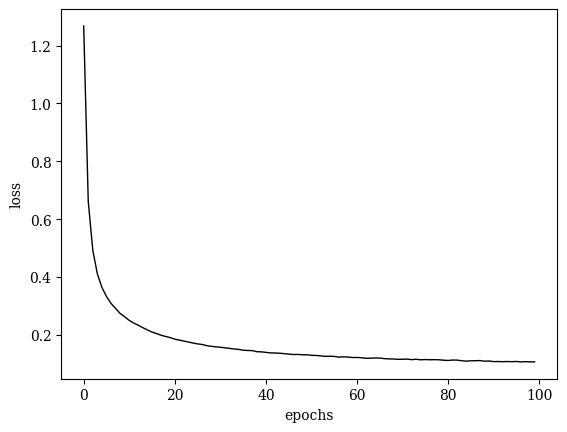

'test_loss: 0.091, test_acc: 0.974'

In [18]:
"""
1. データの準備
"""

mnist = datasets.mnist
(x_train, t_train), (x_test, t_test) = mnist.load_data()

x_train = (x_train.reshape(-1, 784) / 225).astype(np.float32)
x_test = (x_test.reshape(-1, 784) / 225).astype(np.float32)

# 訓練データ:検証データ=8:2に分割
x_train, x_val, t_train, t_val = train_test_split(x_train, t_train, test_size=0.2)


"""
2. モデルの構築
"""
model = Sequential()
model.add(Dense(200, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(200, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(200, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(10, activation="softmax"))

"""
3. モデルの学習
"""
model.compile(
    optimizer="sgd", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)
hist = model.fit(
    x_train,
    t_train,
    epochs=100,
    batch_size=100,
    verbose=2,
    validation_data=(x_val, t_val),
)

"""
4. モデルの評価
"""
# 検証データの誤差の可視化
val_loss = hist.history["val_loss"]  # 誤差の履歴
fig = plt.figure()  # 描画領域を用意
plt.rc("font", family="serif")  # フォント設定
plt.plot(range(len(val_loss)), val_loss, color="black", linewidth=1)  # データの描画
plt.xlabel("epochs")  # x軸のラベルを表示
plt.ylabel("loss")  # y軸のラベルを表示
plt.show()  # グラフを画面に表示

# てすとデータの評価
loss, acc = model.evaluate(x_test, t_test, verbose=0)
display(f"test_loss: {loss:.3f}, test_acc: {acc:.3f}")

#### 4.5.1.2 TensorFlow

In [ ]:
from typing import Any

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras import datasets
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import optimizers
from tensorflow.keras import losses
from tensorflow.keras import metrics

In [ ]:
class DNN(Model):
    def __init__(self, hidden_dim: int, output_dim: int) -> None:
        super().__init__()
        self.l1 = Dense(hidden_dim, activation="relu")
        self.d1 = Dropout(0.5)
        self.l2 = Dense(hidden_dim, activation="relu")
        self.d2 = Dropout(0.5)
        self.l3 = Dense(hidden_dim, activation="relu")
        self.d3 = Dropout(0.5)
        self.l4 = Dense(output_dim, activation="softmax")

        self.ls = [self.l1, self.d1, self.l2, self.d2, self.l3, self.d3, self.l4]

    def call(self, x: np.ndarray) -> np.ndarray:
        for layer in self.ls:
            x = layer(x)
        return x

In [ ]:
np.random.seed(123)
tf.random.set_seed(123)
"""
1. データの準備
"""
mnist = datasets.mnist
(x_train, t_train), (x_test, t_test) = mnist.load_data()

x_train = (x_train.reshape(-1, 784) / 225).astype(np.float32)
x_test = (x_test.reshape(-1, 784) / 225).astype(np.float32)

# 訓練データ:検証データ=8:2に分割
x_train, x_val, t_train, t_val = train_test_split(x_train, t_train, test_size=0.2)

"""
2. モデルの構築
"""
model = DNN(200, 10)

"""
3. モデルの学習
"""
criterion = losses.SparseCategoricalCrossentropy()
optimizer = optimizers.SGD(learning_rate=0.01)
train_loss = metrics.Mean()
train_acc = metrics.SparseCategoricalAccuracy()
val_loss = metrics.Mean()
val_acc = metrics.SparseCategoricalAccuracy()


def compute_loss(t: np.ndarray, y: np.ndarray) -> tf.Tensor:
    return criterion(t, y)


def train_step(
    model: DNN,
    optimizer: Any,
    train_loss: Any,
    train_acc: Any,
    x: np.ndarray,
    t: np.ndarray,
) -> tuple[tf.Tensor, DNN, Any, Any, Any]:
    with tf.GradientTape() as tape:
        preds = model(x)
        loss = compute_loss(t, preds)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    train_loss(loss)
    train_acc(t, preds)
    return loss, model, optimizer, train_loss, train_acc


def val_step(x: np.ndarray, t: np.ndarray) -> tuple[Any, Any]:
    preds = model(x)
    loss = compute_loss(t, preds)
    val_loss(loss)
    val_acc(t, preds)
    return val_loss, val_acc


epochs = 100
batch_size = 100
n_batches_train = x_train.shape[0] // batch_size
n_batches_val = x_val.shape[0] // batch_size
hist = {"val_loss": [], "val_accuracy": []}
for epoch in range(epochs):
    x_, t_ = shuffle(x_train, t_train)
    for batch in range(n_batches_train):
        start = batch * batch_size
        end = start + batch_size
        _, model, optimizer, train_loss, train_acc = train_step(
            model, optimizer, train_loss, train_acc, x_[start:end], t_[start:end]
        )
    for batch in range(n_batches_val):
        start = batch * batch_size
        end = start + batch_size
        val_loss, val_acc = val_step(x_val[start:end], t_val[start:end])
    hist["val_loss"].append(val_loss.result())
    hist["val_accuracy"].append(val_acc.result())
    display(
        f"epoch: {epoch+1}, loss: {train_loss.result():.3}, acc: {train_acc.result():.3}, val_loss: {val_loss.result():.3}, val_acc: {val_acc.result():.3}"
    )

"""
4. モデルの評価
"""
# 検証データの誤差の可視化
val_loss = hist["val_loss"]
fig = plt.figure()
plt.rc("font", family="serif")
plt.plot(range(len(val_loss)), val_loss, color="black", linewidth=1)
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

# テストデータの評価
test_loss = metrics.Mean()
test_acc = metrics.SparseCategoricalAccuracy()


def test_step(
    test_loss: Any, test_acc: Any, x: np.ndarray, t: np.ndarray
) -> tuple[tf.Tensor, Any, Any]:
    preds = model(x)
    loss = compute_loss(t, preds)
    test_loss(loss)
    test_acc(t, preds)
    return loss, test_loss, test_acc


_, test_loss, test_acc = test_step(test_loss, test_acc, x_test, t_test)
display(f"test_loss: {test_loss.result():.3f}, test_acc: {test_acc.result():.3f}")

#### 4.5.1.3 PyTorch

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
import torch.optim as optimizers
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torchvision import datasets
import torchvision.transforms as transforms
from torch.nn.modules import Module
from torch.optim import Optimizer

In [ ]:
class DNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.l1 = nn.Linear(input_dim, hidden_dim)
        self.a1 = nn.ReLU()
        self.d1 = nn.Dropout(0.5)
        self.l2 = nn.Linear(hidden_dim, hidden_dim)
        self.a2 = nn.ReLU()
        self.d2 = nn.Dropout(0.5)
        self.l3 = nn.Linear(hidden_dim, hidden_dim)
        self.a3 = nn.ReLU()
        self.d3 = nn.Dropout(0.5)
        self.l4 = nn.Linear(hidden_dim, output_dim)

        self.layers = [
            self.l1,
            self.a1,
            self.d1,
            self.l2,
            self.a2,
            self.d2,
            self.l3,
            self.a3,
            self.d3,
            self.l4,
        ]

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)

        return x

In [ ]:
np.random.seed(123)
torch.manual_seed(123)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

"""
1. データの準備
"""
root = os.path.join("~", ".torch", "mnist")
transform = transforms.Compose([transforms.ToTensor(), lambda x: x.view(-1)])
mnist_train = datasets.MNIST(root=root, download=True, train=True, transform=transform)
mnist_test = datasets.MNIST(root=root, download=True, train=False, transform=transform)

n_samples = len(mnist_train)
n_train = int(n_samples * 0.8)
n_val = n_samples - n_train

mnist_train, mnist_val = random_split(mnist_train, [n_train, n_val])

train_dataloader = DataLoader(mnist_train, batch_size=100, shuffle=True)
val_dataloader = DataLoader(mnist_val, batch_size=100, shuffle=False)
test_dataloader = DataLoader(mnist_test, batch_size=100, shuffle=False)

"""
2. モデルの構築
"""
model = DNN(784, 200, 10).to(device)

"""
3. モデルの学習
"""
criterion = nn.CrossEntropyLoss()
optimizer = optimizers.SGD(model.parameters(), lr=0.01)


def compute_loss(t: torch.Tensor, y: torch.Tensor) -> Module:
    return criterion(y, t)


def train_step(
    model: Module, optimizer: Optimizer, x: torch.Tensor, t: torch.Tensor
) -> tuple[Module, Module, Module, Optimizer]:
    model.train()
    preds = model(x)
    loss = compute_loss(t, preds)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss, preds, model, optimizer


def val_step(
    model: Module, x: torch.Tensor, t: torch.Tensor
) -> tuple[Module, Module, Module]:
    model.eval()
    preds = model(x)
    loss = criterion(preds, t)

    return loss, preds, model


epochs = 100
hist = {"val_loss": [], "val_accuracy": []}

for epoch in range(epochs):
    train_loss = 0.0
    train_acc = 0.0
    val_loss = 0.0
    val_acc = 0.0

    for x, t in train_dataloader:
        x, t = x.to(device), t.to(device)
        loss, preds, model, optimizer = train_step(model, optimizer, x, t)
        train_loss += loss.item()
        train_acc += accuracy_score(t.tolist(), preds.argmax(dim=-1).tolist())

    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    for x, t in val_dataloader:
        x, t = x.to(device), t.to(device)
        loss, preds, model = val_step(x, t)
        val_loss += loss.item()
        val_acc += accuracy_score(t.tolist(), preds.argmax(dim=-1).tolist())

    val_loss /= len(val_dataloader)
    val_acc /= len(val_dataloader)

    hist["val_loss"].append(val_loss)
    hist["val_accuracy"].append(val_acc)

    print(
        "epoch: {}, loss: {:.3}, acc: {:.3f}"
        ", val_loss: {:.3}, val_acc: {:.3f}".format(
            epoch + 1, train_loss, train_acc, val_loss, val_acc
        )
    )

"""
4. モデルの評価
"""
# 検証データの誤差の可視化
val_loss = hist["val_loss"]

fig = plt.figure()
plt.rc("font", family="serif")
plt.plot(range(len(val_loss)), val_loss, color="black", linewidth=1)
plt.xlabel("epochs")
plt.ylabel("loss")
# plt.savefig('output.jpg')
plt.show()


# テストデータの評価
def test_step(x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    return val_step(x, t)


test_loss = 0.0
test_acc = 0.0

for x, t in test_dataloader:
    x, t = x.to(device), t.to(device)
    loss, preds = test_step(x, t)
    test_loss += loss.item()
    test_acc += accuracy_score(t.tolist(), preds.argmax(dim=-1).tolist())

test_loss /= len(test_dataloader)
test_acc /= len(test_dataloader)
print("test_loss: {:.3f}, test_acc: {:.3f}".format(test_loss, test_acc))

### 4.5.2 早期終了

#### Keras

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import datasets
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

Epoch 1/1000
480/480 - 2s - 4ms/step - accuracy: 0.2680 - loss: 2.0711 - val_accuracy: 0.6741 - val_loss: 1.3755
Epoch 2/1000
480/480 - 1s - 3ms/step - accuracy: 0.5397 - loss: 1.3402 - val_accuracy: 0.8057 - val_loss: 0.7360
Epoch 3/1000
480/480 - 1s - 3ms/step - accuracy: 0.6693 - loss: 0.9697 - val_accuracy: 0.8548 - val_loss: 0.5369
Epoch 4/1000
480/480 - 1s - 3ms/step - accuracy: 0.7430 - loss: 0.7899 - val_accuracy: 0.8754 - val_loss: 0.4448
Epoch 5/1000
480/480 - 1s - 3ms/step - accuracy: 0.7861 - loss: 0.6808 - val_accuracy: 0.8875 - val_loss: 0.3887
Epoch 6/1000
480/480 - 1s - 3ms/step - accuracy: 0.8113 - loss: 0.6100 - val_accuracy: 0.8960 - val_loss: 0.3521
Epoch 7/1000
480/480 - 1s - 3ms/step - accuracy: 0.8293 - loss: 0.5587 - val_accuracy: 0.9020 - val_loss: 0.3256
Epoch 8/1000
480/480 - 1s - 3ms/step - accuracy: 0.8454 - loss: 0.5195 - val_accuracy: 0.9073 - val_loss: 0.3036
Epoch 9/1000
480/480 - 1s - 3ms/step - accuracy: 0.8565 - loss: 0.4858 - val_accuracy: 0.9143 - 

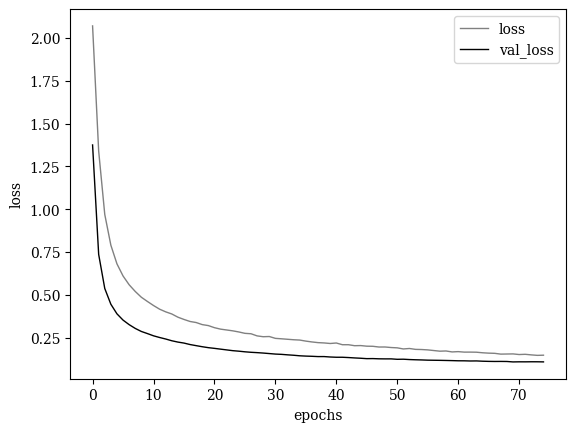

test_loss: 0.098, test_acc: 0.972


In [2]:
np.random.seed(123)
tf.random.set_seed(123)

"""
1. データの準備
"""
mnist = datasets.mnist
(x_train, t_train), (x_test, t_test) = mnist.load_data()

x_train = (x_train.reshape(-1, 784) / 255).astype(np.float32)
x_test = (x_test.reshape(-1, 784) / 255).astype(np.float32)

x_train, x_val, t_train, t_val = train_test_split(x_train, t_train, test_size=0.2)

"""
2. モデルの構築
"""
model = Sequential()
model.add(Dense(200, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(200, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(200, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(10, activation="softmax"))

"""
3. モデルの学習
"""
model.compile(
    optimizer="sgd", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

es = EarlyStopping(monitor="val_loss", patience=5, verbose=1)

hist = model.fit(
    x_train,
    t_train,
    epochs=1000,
    batch_size=100,
    verbose=2,
    validation_data=(x_val, t_val),
    callbacks=[es],
)

"""
4. モデルの評価
"""
# 誤差の可視化
loss = hist.history["loss"]
val_loss = hist.history["val_loss"]

fig = plt.figure()
plt.rc("font", family="serif")
plt.plot(range(len(loss)), loss, color="gray", linewidth=1, label="loss")
plt.plot(range(len(val_loss)), val_loss, color="black", linewidth=1, label="val_loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
# plt.savefig('output.jpg')
plt.show()
# テストデータの評価
loss, acc = model.evaluate(x_test, t_test, verbose=0)
print("test_loss: {:.3f}, test_acc: {:.3f}".format(loss, acc))

#### TensorFlow

In [6]:
from typing import Any

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras import datasets
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import optimizers
from tensorflow.keras import losses
from tensorflow.keras import metrics

In [ ]:
class EarlyStopping:
    """
    早期終了 (early stopping)
    """

    def __init__(self, patience: int = 0, verbose: int = 0) -> None:
        self._step = 0
        self._loss = float("inf")
        self.patience = patience
        self.verbose = verbose

    def __call__(self, loss: float) -> bool:
        if self._loss < loss:
            self._step += 1
            if self._step > self.patience:
                if self.verbose:
                    print("early stopping")
                return True
        else:
            self._step = 0
            self._loss = loss

        return False

In [ ]:
class DNN(Model):
    def __init__(self, hidden_dim: int, output_dim: int) -> None:
        super().__init__()
        self.l1 = Dense(hidden_dim, activation="relu")
        self.d1 = Dropout(0.5)
        self.l2 = Dense(hidden_dim, activation="relu")
        self.d2 = Dropout(0.5)
        self.l3 = Dense(hidden_dim, activation="relu")
        self.d3 = Dropout(0.5)
        self.l4 = Dense(output_dim, activation="softmax")

        self.ls = [self.l1, self.d1, self.l2, self.d2, self.l3, self.d3, self.l4]

    def call(self, x: np.ndarray) -> np.ndarray:
        for layer in self.ls:
            x = layer(x)

        return x

In [9]:
np.random.seed(123)
tf.random.set_seed(123)

"""
1. データの準備
"""
mnist = datasets.mnist
(x_train, t_train), (x_test, t_test) = mnist.load_data()

x_train = (x_train.reshape(-1, 784) / 255).astype(np.float32)
x_test = (x_test.reshape(-1, 784) / 255).astype(np.float32)

x_train, x_val, t_train, t_val = train_test_split(x_train, t_train, test_size=0.2)

"""
2. モデルの構築
"""
model = DNN(200, 10)

"""
3. モデルの学習
"""
criterion = losses.SparseCategoricalCrossentropy()
optimizer = optimizers.SGD(learning_rate=0.01)
train_loss = metrics.Mean()
train_acc = metrics.SparseCategoricalAccuracy()
val_loss = metrics.Mean()
val_acc = metrics.SparseCategoricalAccuracy()


def compute_loss(t: np.ndarray, y: np.ndarray) -> tf.Tensor:
    return criterion(t, y)


def train_step(
    model: DNN,
    optimizer: Any,
    train_loss: Any,
    train_acc: Any,
    x: np.ndarray,
    t: np.ndarray,
) -> tuple[tf.Tensor, DNN, Any, Any, Any]:
    with tf.GradientTape() as tape:
        preds = model(x)
        loss = compute_loss(t, preds)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    train_loss(loss)
    train_acc(t, preds)

    return loss, model, optimizer, train_loss, train_acc


def val_step(
    model: DNN, val_loss: Any, val_acc: Any, x: np.ndarray, t: np.ndarray
) -> tuple[Any, Any]:
    preds = model(x)
    loss = compute_loss(t, preds)
    val_loss(loss)
    val_acc(t, preds)
    return val_loss, val_acc


epochs = 1000
batch_size = 100
n_batches_train = x_train.shape[0] // batch_size
n_batches_val = x_val.shape[0] // batch_size
hist = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
es = EarlyStopping(patience=5, verbose=1)

for epoch in range(epochs):
    x_, t_ = shuffle(x_train, t_train)

    for batch in range(n_batches_train):
        start = batch * batch_size
        end = start + batch_size
        _, model, optimizer, train_loss, train_acc = train_step(
            model, optimizer, train_loss, train_acc, x_[start:end], t_[start:end]
        )

    for batch in range(n_batches_val):
        start = batch * batch_size
        end = start + batch_size
        val_loss, val_acc = val_step(
            model, val_loss, val_acc, x_val[start:end], t_val[start:end]
        )

    hist["loss"].append(train_loss.result())
    hist["accuracy"].append(train_acc.result())
    hist["val_loss"].append(val_loss.result())
    hist["val_accuracy"].append(val_acc.result())

    print(
        "epoch: {}, loss: {:.3}, acc: {:.3f}"
        ", val_loss: {:.3}, val_acc: {:.3f}".format(
            epoch + 1,
            train_loss.result(),
            train_acc.result(),
            val_loss.result(),
            val_acc.result(),
        )
    )

    if es(val_loss.result()):  # 早期終了判定
        break

epoch: 1, loss: 1.37, acc: 0.647, val_loss: 0.624, val_acc: 0.835
epoch: 2, loss: 0.919, acc: 0.761, val_loss: 0.508, val_acc: 0.861
epoch: 3, loss: 0.729, acc: 0.807, val_loss: 0.447, val_acc: 0.876
epoch: 4, loss: 0.623, acc: 0.834, val_loss: 0.409, val_acc: 0.885
epoch: 5, loss: 0.553, acc: 0.851, val_loss: 0.381, val_acc: 0.892
epoch: 6, loss: 0.503, acc: 0.864, val_loss: 0.36, val_acc: 0.897
epoch: 7, loss: 0.465, acc: 0.874, val_loss: 0.342, val_acc: 0.902
epoch: 8, loss: 0.434, acc: 0.882, val_loss: 0.328, val_acc: 0.905
epoch: 9, loss: 0.409, acc: 0.888, val_loss: 0.315, val_acc: 0.909
epoch: 10, loss: 0.387, acc: 0.894, val_loss: 0.304, val_acc: 0.912
epoch: 11, loss: 0.369, acc: 0.899, val_loss: 0.295, val_acc: 0.915
epoch: 12, loss: 0.353, acc: 0.903, val_loss: 0.286, val_acc: 0.917
epoch: 13, loss: 0.339, acc: 0.907, val_loss: 0.278, val_acc: 0.919
epoch: 14, loss: 0.326, acc: 0.910, val_loss: 0.27, val_acc: 0.921
epoch: 15, loss: 0.314, acc: 0.913, val_loss: 0.264, val_acc

#### PyTorch

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
import torch.optim as optimizers
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torchvision import datasets
import torchvision.transforms as transforms
from torch.nn.modules import Module
from torch.optim import Optimizer

In [ ]:
class DNN(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int) -> None:
        super().__init__()
        self.l1 = nn.Linear(input_dim, hidden_dim)
        self.a1 = nn.ReLU()
        self.d1 = nn.Dropout(0.5)
        self.l2 = nn.Linear(hidden_dim, hidden_dim)
        self.a2 = nn.ReLU()
        self.d2 = nn.Dropout(0.5)
        self.l3 = nn.Linear(hidden_dim, hidden_dim)
        self.a3 = nn.ReLU()
        self.d3 = nn.Dropout(0.5)
        self.l4 = nn.Linear(hidden_dim, output_dim)

        self.layers = [
            self.l1,
            self.a1,
            self.d1,
            self.l2,
            self.a2,
            self.d2,
            self.l3,
            self.a3,
            self.d3,
            self.l4,
        ]

    def forward(self, x: np.ndarray) -> np.ndarray:
        for layer in self.layers:
            x = layer(x)

        return x

In [ ]:
np.random.seed(123)
torch.manual_seed(123)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

"""
1. データの準備
"""
root = os.path.join("~", ".torch", "mnist")
transform = transforms.Compose([transforms.ToTensor(), lambda x: x.view(-1)])
mnist_train = datasets.MNIST(root=root, download=True, train=True, transform=transform)
mnist_test = datasets.MNIST(root=root, download=True, train=False, transform=transform)

n_samples = len(mnist_train)
n_train = int(n_samples * 0.8)
n_val = n_samples - n_train

mnist_train, mnist_val = random_split(mnist_train, [n_train, n_val])

train_dataloader = DataLoader(mnist_train, batch_size=100, shuffle=True)
val_dataloader = DataLoader(mnist_val, batch_size=100, shuffle=False)
test_dataloader = DataLoader(mnist_test, batch_size=100, shuffle=False)

"""
2. モデルの構築
"""
model = DNN(784, 200, 10).to(device)

"""
3. モデルの学習
"""
criterion = nn.CrossEntropyLoss()
optimizer = optimizers.SGD(model.parameters(), lr=0.01)


def compute_loss(t: torch.Tensor, y: torch.Tensor) -> Module:
    return criterion(y, t)


def train_step(
    model: Module, optimizer: Optimizer, x: torch.Tensor, t: torch.Tensor
) -> tuple[Module, Module, Module, Optimizer]:
    model.train()
    preds = model(x)
    loss = compute_loss(t, preds)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss, preds, model, optimizer


def val_step(
    model: Module, x: torch.Tensor, t: torch.Tensor
) -> tuple[Module, Module, Module]:
    model.eval()
    preds = model(x)
    loss = criterion(preds, t)

    return loss, preds, model


epochs = 1000
hist = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
es = EarlyStopping(patience=5, verbose=1)

for epoch in range(epochs):
    train_loss = 0.0
    train_acc = 0.0
    val_loss = 0.0
    val_acc = 0.0

    for x, t in train_dataloader:
        x, t = x.to(device), t.to(device)
        loss, preds, model, optimizer = train_step(x, t)
        train_loss += loss.item()
        train_acc += accuracy_score(t.tolist(), preds.argmax(dim=-1).tolist())

    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    for x, t in val_dataloader:
        x, t = x.to(device), t.to(device)
        loss, preds = val_step(x, t)
        val_loss += loss.item()
        val_acc += accuracy_score(t.tolist(), preds.argmax(dim=-1).tolist())

    val_loss /= len(val_dataloader)
    val_acc /= len(val_dataloader)

    hist["loss"].append(train_loss)
    hist["accuracy"].append(train_acc)
    hist["val_loss"].append(val_loss)
    hist["val_accuracy"].append(val_acc)

    print(
        "epoch: {}, loss: {:.3}, acc: {:.3f}"
        ", val_loss: {:.3}, val_acc: {:.3f}".format(
            epoch + 1, train_loss, train_acc, val_loss, val_acc
        )
    )

    if es(val_loss):  # 早期終了判定
        break

"""
4. モデルの評価
"""
# 検証データの誤差の可視化
loss = hist["loss"]
val_loss = hist["val_loss"]

fig = plt.figure()
plt.rc("font", family="serif")
plt.plot(range(len(loss)), loss, color="gray", linewidth=1, label="loss")
plt.plot(range(len(val_loss)), val_loss, color="black", linewidth=1, label="val_loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
# plt.savefig('output.jpg')
plt.show()


# テストデータの評価
def test_step(x, t):
    return val_step(x, t)


test_loss = 0.0
test_acc = 0.0

for x, t in test_dataloader:
    x, t = x.to(device), t.to(device)
    loss, preds = test_step(x, t)
    test_loss += loss.item()
    test_acc += accuracy_score(t.tolist(), preds.argmax(dim=-1).tolist())

test_loss /= len(test_dataloader)
test_acc /= len(test_dataloader)
print("test_loss: {:.3f}, test_acc: {:.3f}".format(test_loss, test_acc))

## 4.6 学習率の設定

### 4.6.1 モメンタム

#### Keras

In [ ]:
# 以下部分のみ修正
from tensorflow.keras import optimizers


optimizer = optimizers.SGD(learning_rate=0.01, momentum=0.9)  # モメンタム

#### TensorFlow

Kerasと同じ

#### PyTorch

In [ ]:
optimizer = optimizers.SGD(model.parameters(), lr=0.01, momentum=0.9)  # モメンタム

### 4.6.2 Nesterov モメンタム

#### Keras, TensorFlow

In [ ]:
optimizer = optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

#### PyTorch

In [ ]:
optimizer = optimizers.SGD(model.parameters(), lr=0.01, momentum=0.9, nesterov=True)

### 4.6.3 AdaGrad

#### Keras, TensorFlow

In [ ]:
optimizer = optimizers.Adagrad(learning_rate=0.01)

#### PyTorch

In [ ]:
optimizer = optimizers.Adagrad(model.parameters(), lr=0.01)

### 4.6.4 RMSProp

#### Keras, TensorFlow

In [ ]:
optimizer = optimizers.RMSprop(learning_rate=0.001, rho=0.99)

#### PyTorch

In [ ]:
optimizer = optimizers.RMSprop(model.parameters(), lr=0.001, alpha=0.99)

### 4.6.5 Adadelta

#### Keras, TensorFlow

In [ ]:
optimizer = optimizers.Adadelta(rho=0.95)

#### PyTorch

In [ ]:
optimizer = optimizers.Adadelta(model.parameters(), rho=0.95)

#### 4.6.6 Adam

#### Keras, TensorFlow

In [ ]:
optimizer = optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

#### PyTorch

In [ ]:
optimizer = optimizers.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999))

### 4.6.7 AMSGrad

#### Keras, TensorFlow

In [ ]:
optimizer = optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, amsgrad=True)

#### PyTorch

In [ ]:
optimizer = optimizers.Adam(
    model.parameters(), lr=0.001, betas=(0.9, 0.999), amsgrad=True
)

## 4.7 重みの初期化

### 4.7.2 実装

#### Keras, TensorFlow

In [ ]:
## 層の引数で初期化設定
# He(ReLU)の初期化
model.add(Dense(hidden_dim, activation="relu", kernel_initializer="he_normal"))

# Xavier(対称性もつ活性化関数)の初期化
model.add(Dense(hidden_dim, activation="relu", kernel_initializer="glorot_normal"))

#### PyTorch

In [ ]:
# He(ReLU)の初期化
l = nn.Linear(hidden_dim, hidden_dim)
nn.init.kaiming_normal_(l.weight)

# Xavier(対称性もつ活性化関数)の初期化
l = nn.Linear(hidden_dim, hidden_dim)
nn.init.xavier_normal_(l.weight)


# 実装例
class DNN(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int) -> None:
        super().__init__()
        self.l1 = nn.Linear(input_dim, hidden_dim)
        self.a1 = nn.ReLU()
        self.d1 = nn.Dropout(0.5)
        self.l2 = nn.Linear(hidden_dim, hidden_dim)
        self.a2 = nn.ReLU()
        self.d2 = nn.Dropout(0.5)
        self.l3 = nn.Linear(hidden_dim, hidden_dim)
        self.a3 = nn.ReLU()
        self.d3 = nn.Dropout(0.5)
        self.l4 = nn.Linear(hidden_dim, output_dim)

        self.layers = [
            self.l1,
            self.a1,
            self.d1,
            self.l2,
            self.a2,
            self.d2,
            self.l3,
            self.a3,
            self.d3,
            self.l4,
        ]

        for layer in self.layers:
            if type(layer) == nn.Linear:
                nn.init.kaiming_normal_(layer.weight)  # Heの初期化

## 4.8 バッチ正規化

### 4.8.2 実装

#### Keras

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import datasets
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, BatchNormalization
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# 処理の順番に書いていくのでDense->BatchNormalization->Activation->Dropoutとなる
model = Sequential()
model.add(Dense(200, kernel_initializer="he_normal"))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Dropout(0.5))
model.add(Dense(200, kernel_initializer="he_normal"))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Dropout(0.5))
model.add(Dense(200, kernel_initializer="he_normal"))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Dropout(0.5))
model.add(Dense(10, kernel_initializer="he_normal", activation="softmax"))

#### TensorFlow

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras import datasets
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Activation, BatchNormalization
from tensorflow.keras import optimizers
from tensorflow.keras import losses
from tensorflow.keras import metrics

In [ ]:
class EarlyStopping:
    """
    早期終了 (early stopping)
    """

    def __init__(self, patience: int = 0, verbose: int = 0) -> None:
        self._step = 0
        self._loss = float("inf")
        self.patience = patience
        self.verbose = verbose

    def __call__(self, loss: float) -> bool:
        if self._loss < loss:
            self._step += 1
            if self._step > self.patience:
                if self.verbose:
                    print("early stopping")
                return True
        else:
            self._step = 0
            self._loss = loss

        return False

In [ ]:
class DNN(Model):
    def __init__(self, hidden_dim: int, output_dim: int) -> None:
        super().__init__()
        self.l1 = Dense(hidden_dim, kernel_initializer="he_normal")
        self.b1 = BatchNormalization()
        self.a1 = Activation("relu")
        self.d1 = Dropout(0.5)
        self.l2 = Dense(hidden_dim, kernel_initializer="he_normal")
        self.b2 = BatchNormalization()
        self.a2 = Activation("relu")
        self.d2 = Dropout(0.5)
        self.l3 = Dense(hidden_dim, kernel_initializer="he_normal")
        self.b3 = BatchNormalization()
        self.a3 = Activation("relu")
        self.d3 = Dropout(0.5)
        self.l4 = Dense(
            output_dim, kernel_initializer="he_normal", activation="softmax"
        )

        self.ls = [
            self.l1,
            self.b1,
            self.a1,
            self.d1,
            self.l2,
            self.b2,
            self.a2,
            self.d2,
            self.l3,
            self.b3,
            self.a3,
            self.d3,
            self.l4,
        ]

    def call(self, x: np.ndarray) -> np.ndarray:
        for layer in self.ls:
            x = layer(x)

        return x

#### PyTorch

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
import torch.optim as optimizers
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torchvision import datasets
import torchvision.transforms as transforms

In [ ]:
class DNN(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int) -> None:
        super().__init__()
        self.l1 = nn.Linear(input_dim, hidden_dim)
        self.b1 = nn.BatchNorm1d(hidden_dim)
        self.a1 = nn.ReLU()
        self.d1 = nn.Dropout(0.5)
        self.l2 = nn.Linear(hidden_dim, hidden_dim)
        self.b2 = nn.BatchNorm1d(hidden_dim)
        self.a2 = nn.ReLU()
        self.d2 = nn.Dropout(0.5)
        self.l3 = nn.Linear(hidden_dim, hidden_dim)
        self.b3 = nn.BatchNorm1d(hidden_dim)
        self.a3 = nn.ReLU()
        self.d3 = nn.Dropout(0.5)
        self.l4 = nn.Linear(hidden_dim, output_dim)

        self.layers = [
            self.l1,
            self.b1,
            self.a1,
            self.d1,
            self.l2,
            self.b2,
            self.a2,
            self.d2,
            self.l3,
            self.b3,
            self.a3,
            self.d3,
            self.l4,
        ]

        for layer in self.layers:
            if type(layer) == nn.Linear:
                nn.init.kaiming_normal_(layer.weight)

    def forward(self, x: np.ndarray) -> np.ndarray:
        for layer in self.layers:
            x = layer(x)

        return x